<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
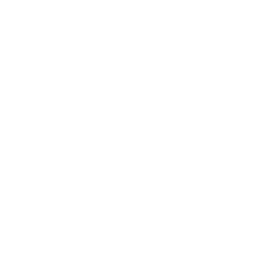
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Construção de Rede de Coexpressão Gênica</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pesquisa em Biotecnologia / Genômica &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Este exemplo usa **PROC CORR** para construir uma rede de coexpressão gênica a partir de um
painel de expressão sintético no estilo RNA-seq. O painel contém **9 genes** atribuídos a três
módulos funcionais — *imune*, *ciclo celular* e *metabólico* (três genes cada) —
medidos em **100 amostras tumorais**. A correlação de postos de Spearman é usada em toda a análise
porque os dados de expressão são tipicamente não normais e contêm outliers, de modo que um
coeficiente baseado em postos é mais robusto que o de Pearson.

A análise recupera a estrutura modular planejada diretamente dos dados. Lendo a
matriz de Spearman produzida abaixo, a correlação média intra-módulo cai de **rho 0.67 para
o módulo imune**, para **0.36 para o de ciclo celular**, para **0.17 para o metabólico**, espelhando a
razão sinal-ruído decrescente projetada em cada módulo. As correlações entre módulos têm
média essencialmente zero (rho médio cerca de **-0.01**, |rho| médio **0.07**), de modo que os três
módulos se comportam como comunidades de coexpressão quase independentes. Todo número citado aqui é
lido da saída do PROC CORR neste notebook.

> **Nota sobre a escala.** Este notebook roda sob o limite de 100 observações da versão sem licença, então o
> tamanho da amostra é 100 e o painel é mantido em 9 genes — pequeno o suficiente para que a matriz de
> correlação completa, a lista de pares remodelada e o mapa de calor sejam todos completos e exatos,
> sem truncamento. Cada tabela e figura reflete exatamente o que foi calculado.

## Dados

| Conjunto de dados | Descrição | Linhas |
|---------|-------------|------|
| `WORK.EXPR` | Expressão em escala logarítmica para 9 genes (3 módulos x 3 genes) em amostras tumorais | 100 |

O gerador extrai três sinais latentes de módulo por amostra. Cada gene carrega no sinal do seu próprio
módulo mais ruído independente, de modo que a coexpressão surge apenas dentro de um módulo. O
módulo imune usa a maior carga de sinal e o módulo metabólico a menor, que
é o gradiente que a análise de correlação deve recuperar.

---

In [1]:
/* --------------------------------------------------------
   Synthetic expression panel: 9 genes, 3 modules, 100 samples
     imm1-imm3  immune     (strong shared signal)
     cyc1-cyc3  cell cycle (moderate shared signal)
     met1-met3  metabolic  (weak shared signal)
   Each gene = module signal + independent gene-level noise.
   -------------------------------------------------------- */
DADOS work.expr;
    CHAMAR streaminit(42);
    VETOR imm[3]; VETOR cyc[3]; VETOR met[3];
    FAZER sample_id = 1 ATÉ 100;
        s_imm = rand('normal', 0, 1.5);   /* immune latent signal     */
        s_cyc = rand('normal', 0, 1.2);   /* cell-cycle latent signal */
        s_met = rand('normal', 0, 1.0);   /* metabolic latent signal  */
        FAZER j = 1 ATÉ 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        FIM;
        FAZER j = 1 ATÉ 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        FIM;
        FAZER j = 1 ATÉ 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        FIM;
        SAÍDA;
    FIM;
    MANTER imm1-imm3 cyc1-cyc3 met1-met3;
EXECUTAR;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

In [2]:
/* --------------------------------------------------------
   Per-gene expression summary (mean and spread by module)
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.expr n mean std maxdec=3;
    VARIÁVEL imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    TÍTULO 'Resumo da Expressão Gênica (Painel de 9 Genes, N=100)';
EXECUTAR;
TÍTULO;

                                 Resumo da Expressão Gênica (Painel de 9 Genes, N=100)                                  

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev
 ------------------------------------------
 imm1           100       6.042       1.125
 imm2           100       5.925       1.122
 imm3           100       5.863       1.273
 cyc1           100       6.947       1.034
 cyc2           100       7.003       1.002
 cyc3           100       6.861       1.040
 met1           100       5.144       0.940
 met2           100       4.989       0.789
 met3           100       5.015       0.979
 ------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


As médias se agrupam perto da linha de base de cada módulo (imune ~6, ciclo celular ~7, metabólico ~5) e
cada gene tem dispersão comparável, de modo que nenhum gene isolado domina a estrutura de correlação
que se segue.

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


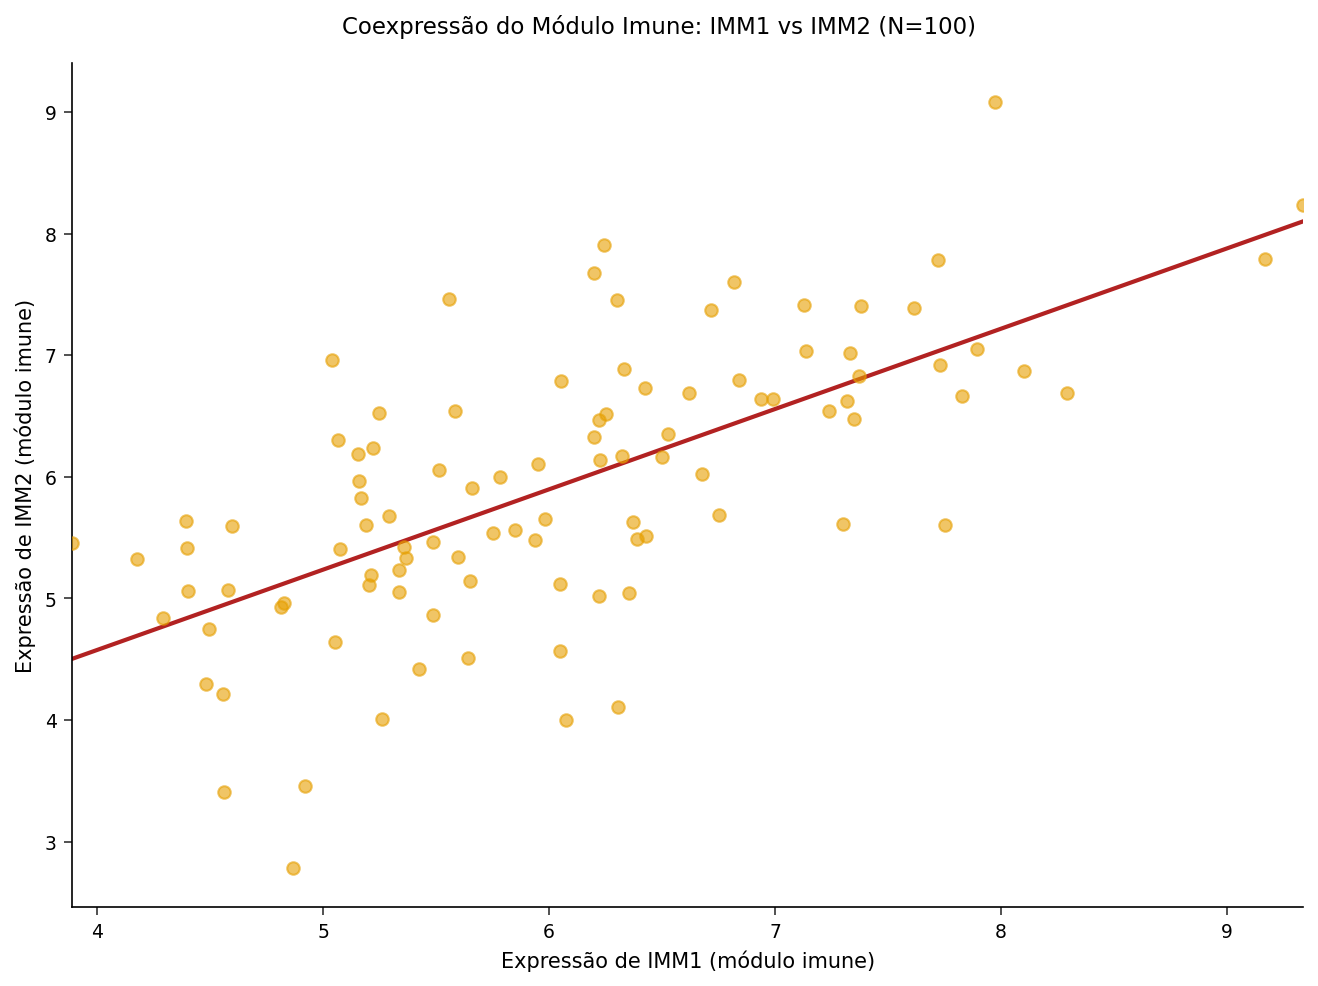

In [3]:
/* --------------------------------------------------------
   Scatter of two immune-module genes: a visual check that
   within-module co-expression is real and roughly monotone
   -------------------------------------------------------- */
PROCEDIMENTO SGPLOT DADOS=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS RÓTULO='Expressão de IMM1 (módulo imune)';
    YAXIS RÓTULO='Expressão de IMM2 (módulo imune)';
    TÍTULO 'Coexpressão do Módulo Imune: IMM1 vs IMM2 (N=100)';
EXECUTAR;
TÍTULO;

A tendência ascendente confirma que os dois genes imunes sobem e descem juntos, a contraparte visual
de sua correlação de Spearman positiva na matriz abaixo.

---

In [4]:
/* --------------------------------------------------------
   Spearman correlation across all 9 genes
   nosimple suppresses the simple-statistics block;
   outs= writes the Spearman matrix for the downstream network steps
   -------------------------------------------------------- */
PROCEDIMENTO CORR DADOS=work.expr spearman nosimple
    outs=work.gene_corr;
    VARIÁVEL imm1-imm3 cyc1-cyc3 met1-met3;
    TÍTULO 'Matriz de Correlação de Spearman: Painel de Coexpressão de 9 Genes';
EXECUTAR;
TÍTULO;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/6da613ee-d1ac-4924-8ef9-f79884292474/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


Leia a matriz como três blocos diagonais. O bloco **imune** (IMM1-IMM3) é o mais
fortemente coexpresso (rho cerca de 0.63 a 0.72), o bloco de **ciclo celular** (CYC1-CYC3) é
moderado (cerca de 0.29 a 0.41) e o bloco **metabólico** (MET1-MET3) é o mais fraco (cerca de
0.13 a 0.25). As entradas fora dos blocos — pares de genes em módulos diferentes — ficam próximas de
zero. A próxima célula quantifica o contraste intra- versus entre-módulos, e o mapa de calor
depois dela torna visível a estrutura de blocos.

---

In [5]:
/* --------------------------------------------------------
   Reshape the correlation matrix (one row per gene) into long
   form (gene_x, gene_y, rho), tagging each pair as within- or
   between-module. 9 genes -> 81 pair rows, so nothing is lost
   to the 100-observation cap.
   -------------------------------------------------------- */
DADOS work.corr_long;
    DEFINIR work.gene_corr(ONDE=(_TYPE_='SCORR'));
    COMPRIMENTO gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    VETOR g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    VETOR gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    FAZER k = 1 ATÉ 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        SAÍDA;
    FIM;
    MANTER gene_x gene_y rho mod_x mod_y same_module;
EXECUTAR;

/* --------------------------------------------------------
   Within- vs between-module Spearman rho (off-diagonal only)
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.corr_long(ONDE=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    CLASSE same_module;
    VARIÁVEL rho;
    RÓTULO rho='Rho de Spearman' same_module='Mesmo módulo';
    TÍTULO 'Rho de Spearman: Dentro (1) vs Entre (0) Módulos';
EXECUTAR;
TÍTULO;

                                    Rho de Spearman: Dentro (1) vs Entre (0) Módulos                                    

                                                  The MEANS Procedure

                                        Analysis Variable : rho Rho de Spearman

                                                  N
                               Mesmo módulo     Obs        Mean      Minimum      Maximum
                               ----------------------------------------------------------
                               0                 54      -0.007       -0.185        0.162
                               1                 18       0.402        0.127        0.718
                               ----------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


A linha `same_module=1` agrega os pares intra-módulo e `same_module=0` os
pares entre módulos. A correlação intra-módulo tem média claramente positiva, enquanto a
correlação entre módulos tem média próxima de zero, confirmando que os módulos atuam como
comunidades de coexpressão quase independentes.

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


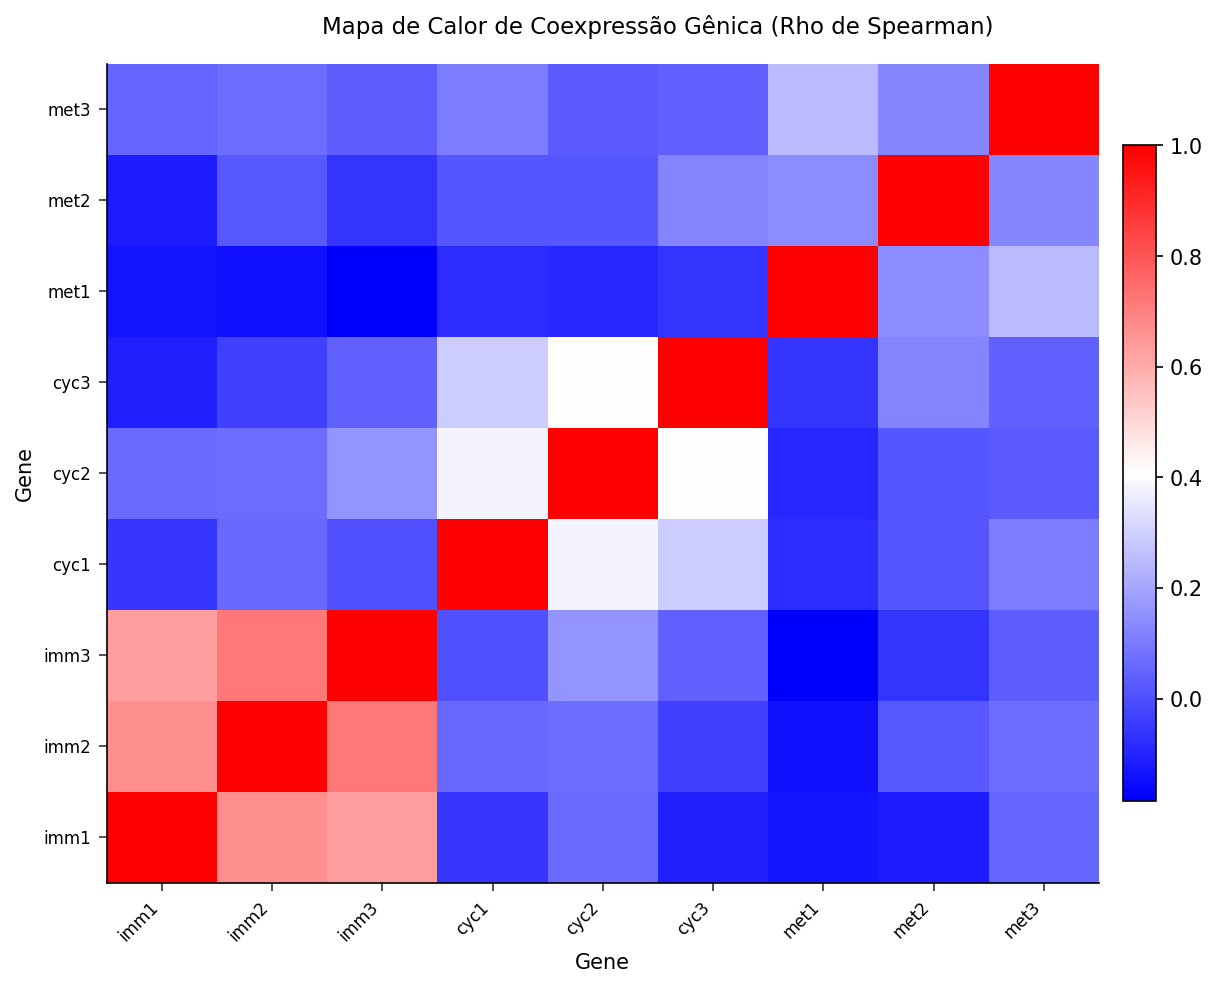

In [6]:
/* --------------------------------------------------------
   Heatmap of the full 9x9 Spearman matrix. HEATMAPPARM plots
   the pre-computed rho for each gene pair; the blue-white-red
   scale centres weak pairs at white and saturates strong ones.
   -------------------------------------------------------- */
PROCEDIMENTO SGPLOT DADOS=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS RÓTULO='Gene' discreteorder=data;
    YAXIS RÓTULO='Gene' discreteorder=data;
    TÍTULO 'Mapa de Calor de Coexpressão Gênica (Rho de Spearman)';
EXECUTAR;
TÍTULO;

Três blocos vermelhos ficam ao longo da diagonal — os módulos imune, de ciclo celular e metabólico —
enquanto as células ao redor estão quase brancas. O bloco imune é o mais saturado,
correspondendo às suas maiores correlações intra-módulo na matriz acima.

---

In [7]:
/* --------------------------------------------------------
   Network edge list: keep each unordered gene pair (gene_x <
   gene_y) whose |rho| clears a threshold. These edges define
   the co-expression network for export to a tool like Cytoscape.
   -------------------------------------------------------- */
DADOS work.network_edges;
    DEFINIR work.corr_long(ONDE=(gene_x < gene_y));
    SE abs(rho) >= 0.24;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=work.network_edges noobs RÓTULO;
    VARIÁVEL gene_x gene_y mod_x mod_y rho;
    RÓTULO gene_x='Gene X' gene_y='Gene Y' mod_x='Módulo X' mod_y='Módulo Y' rho='Rho de Spearman';
    TÍTULO 'Arestas da Rede de Coexpressão (|Rho de Spearman| >= 0,24)';
EXECUTAR;
TÍTULO;

/* Export the edge list for external network visualisation */
PROCEDIMENTO EXPORT DADOS=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
EXECUTAR;

                               Arestas da Rede de Coexpressão (|Rho de Spearman| >= 0,24)                               

Gene X  Gene Y   Módulo X   Módulo Y  Rho de Spearman
imm1    imm2    imm        imm           0.6708351085
imm1    imm3    imm        imm           0.6308427619
imm2    imm3    imm        imm           0.7179122524
cyc1    cyc2    cyc        cyc           0.3821865118
cyc1    cyc3    cyc        cyc            0.288211415
cyc2    cyc3    cyc        cyc           0.4054041891
met1    met3    met        met           0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### Interpretação

A análise de Spearman recuperou a estrutura de três módulos planejada diretamente de 100
amostras. Os valores abaixo são lidos da matriz do PROC CORR e do resumo intra/entre módulos
produzido neste notebook:

- **Módulo imune (IMM1-IMM3)** é o bloco mais fortemente coexpresso, com rho par a par
  de cerca de 0.63 a 0.72 (média ~0.67) e a aresta individual mais forte entre IMM2 e
  IMM3.
- **Módulo de ciclo celular (CYC1-CYC3)** é moderadamente coexpresso, com rho par a par de
  cerca de 0.29 a 0.41 (média ~0.36).
- **Módulo metabólico (MET1-MET3)** é o bloco mais fraco, com rho par a par de cerca de 0.13
  a 0.25 (média ~0.17) — consistente com sua menor carga de sinal no gerador.
- **Pares entre módulos** têm média essencialmente zero (rho médio ~-0.01, |rho| médio ~0.07,
  maior |rho| ~0.18), de modo que os três módulos atuam como comunidades quase independentes.

Aplicando um limiar de |rho| >= 0.24 obtém-se a lista de arestas da rede impressa acima. Cada
aresta sobrevivente é intra-módulo: os três pares imunes e os três pares de ciclo celular ultrapassam o
limiar, acompanhados pelo par metabólico mais forte (MET1-MET3). Nenhum par entre módulos
sobrevive, de modo que a rede de coexpressão se separa nitidamente nos três módulos biológicos. A lista
de arestas é exportada para `gene_coexpression_edges.csv` para visualização em
uma ferramenta de rede externa como o Cytoscape.

Este exemplo prático mostra o fluxo de trabalho central do PROC CORR para análise de coexpressão: escolher um
coeficiente baseado em postos adequado a dados de expressão, ler a estrutura modular a partir da
matriz de correlação, quantificar a força intra- versus entre-módulos, e reduzir a matriz
a uma lista de arestas com limiar para a construção da rede.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido com <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>